In [1]:
# ── Basic Chatbot ────────────────────────────────────────────
# Goal  : build the simplest LangGraph chatbot — one node that sends every
#         message to a Mistral LLM and returns the reply.
# Concepts: StateGraph, ChatState, add_messages reducer, graph.compile(),
#           graph.invoke()
# ─────────────────────────────────────────────────────────────────────────
# Install required packages:
#   langgraph           – graph orchestration framework
#   langchain-mistralai – Mistral AI chat integration
#   dotenv              – load API keys from a .env file

!uv pip install langgraph langchain-mistralai dotenv --quiet

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────
# TypedDict / Annotated  – define a typed state schema for the graph
# BaseMessage / HumanMessage – LangChain message types
# ChatMistralAI          – wrapper around the Mistral chat API
# add_messages           – reducer: appends new msgs instead of overwriting
# StateGraph             – main LangGraph class for building workflows
# START / END            – sentinel nodes for graph entry and exit
# MemorySaver            – in-RAM checkpointer (not used in this notebook)

from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [3]:
# Load environment variables from .env.
# MISTRAL_API_KEY must be defined there for ChatMistralAI to authenticate.

load_dotenv()

True

In [4]:
# Define the graph state — holds the full message history.
# add_messages is a reducer that appends new messages instead of overwriting.
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
# ── LLM Initialisation ───────────────────────────────────────────────────
# ChatMistralAI() reads MISTRAL_API_KEY from the environment automatically.

llm = ChatMistralAI()

def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [6]:
# Build the graph: single node that calls the LLM.
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

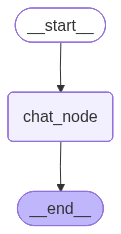

In [7]:
chatbot

In [8]:
# initial_state = {
#     'messages': [HumanMessage(content="What is the capital of India?")]
# }
# chatbot.invoke(initial_state)['messages'][-1].content

In [9]:
# Simple chat loop — no memory between runs; every invoke starts fresh.
thread_id = '1'

while True:

    user_query = input('Ask your query: ')

    print('User: ', user_query)

    if user_query.strip().lower() in ['exit', 'bye', 'fuck you', 'quit']:
        print('AI: Hope you got answers')
        break

    response = chatbot.invoke({ 
        'messages' : [HumanMessage(content=user_query)]        
    })

    print('AI: ', response['messages'][-1].content)

User:  


HTTPStatusError: Error response 401 while fetching https://api.mistral.ai/v1/chat/completions: {"detail":"Unauthorized"}